# ML-10 - Content Action Playbook

This playbook turns the validated refresh queue into a human-reviewed operating plan. It is decision support: the score helps order attention, while a reviewer decides what to change.

**Source:** the repository's ranked queue and model report.

**Output:** a reproducible queue export, metrics receipt, and reusable figures under `work/outputs/` and `work/figures/`.

> Claims below use observed, measured, directional, and decision-support language. The declining label is a current-window proxy, not a future outcome.

## 1. Ranked actions + reason codes

The queue is ordered by `final_refresh_score`. Start with high-confidence, visible pages that carry a clear reason code. The action is not "publish this change"; it is "open this page and decide whether the evidence supports a refresh."

| Queue condition | Suggested action | Reviewer question |
|---|---|---|
| `refresh_and_review_ctr` | Inspect title/snippet intent and search-result fit | Is the page visible but earning weaker click-through than its context suggests? |
| `refresh_and_review_engagement` | Inspect opening, structure, and usefulness | Is the page attracting visits but failing to hold attention? |
| `refresh` | Review for a focused content update | Is there enough demand and model support to justify a refresh pass? |
| `expand_and_refresh` | Consider adding missing depth after review | What useful coverage is absent, and can it be supported by evidence? |
| `monitor` | Do not edit automatically; watch the next review cycle | Is the signal too weak or mixed to justify work now? |

Reason codes are the handoff language. They explain why a row entered the queue and keep the model from becoming a black box.

In [8]:
from pathlib import Path
import json
import shutil
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "outputs" / "refresh_queue_sample.csv").exists():
    REPO_ROOT = Path.cwd().parents[1]

source_candidates = [
    REPO_ROOT / "outputs" / "refresh_queue_sample.csv",
    REPO_ROOT / "work" / "outputs" / "w07_ranked_action_queue.csv",
]
source_queue = next((path for path in source_candidates if path.exists()), None)
if source_queue is None:
    raise FileNotFoundError("Could not find the ranked queue export.")

queue = pd.read_csv(source_queue)
queue["final_reason_codes"] = queue["final_reason_codes"].fillna("")
queue["reason_code_count"] = queue["final_reason_codes"].str.count("\\|") + queue["final_reason_codes"].ne("").astype(int)

print(f"Loaded {len(queue):,} ranked rows from {source_queue.relative_to(REPO_ROOT)}")
print("Suggested actions:")
print(queue["suggested_action"].value_counts().to_string())
print("\\nTop five rows:")
print(queue[["final_rank", "final_refresh_score", "confidence", "suggested_action", "final_reason_codes"]].head().to_string(index=False))

Loaded 200 ranked rows from outputs\refresh_queue_sample.csv
Suggested actions:
suggested_action
refresh_and_review_ctr           130
refresh                           35
refresh_and_review_engagement     35
\nTop five rows:
 final_rank  final_refresh_score confidence       suggested_action                                                                                                                                                   final_reason_codes
          1            81.636697       high refresh_and_review_ctr declining_with_demand|low_ctr_visible_page|low_engagement_visible_page|model_decline_risk|visible_model_opportunity|ctr_review_candidate|engagement_review_candidate
          2            81.447656       high refresh_and_review_ctr                                                         declining_with_demand|low_ctr_visible_page|model_decline_risk|visible_model_opportunity|ctr_review_candidate
          3            81.430346     medium refresh_and_review_ctr             

## 2. Intended use and limits

**Intended user:** a content strategist or SEO reviewer with limited weekly capacity.

**Intended use:** use the ranked queue as a first-pass ordering tool. Open the highest-ranked plausible opportunities, read the reason codes, inspect the page and surrounding search context, then choose `refresh`, `expand`, `monitor`, or no action.

**What the measured result supports:** on the recorded client-holdout evaluation, the Random Forest ranked the top 50 more precisely than the baseline rule (`0.740` versus `0.240` Precision@50). That is an observed comparison on this dataset and split, not proof that a refresh will improve ranking, traffic, or conversion.

**Limits:** the target is a current-window declining proxy, not a future outcome; the data is anonymized and page-level; the model does not predict or reverse-engineer Google's algorithm; thin-signal pages can be hard to distinguish; and the queue is not a publishing command.

In [9]:
action_summary = (queue.groupby("suggested_action", dropna=False)
                  .agg(rows=("final_rank", "size"),
                       median_score=("final_refresh_score", "median"),
                       median_probability=("best_model_probability", "median"))
                  .sort_values("rows", ascending=False))

reason_summary = (queue.assign(reason=queue["final_reason_codes"].str.split("|"))
                  .explode("reason")
                  .query("reason != ''")
                  .groupby("reason")
                  .size()
                  .sort_values(ascending=False)
                  .head(10))

print("Action summary:")
print(action_summary.round(3).to_string())
print("\\nTop reason codes:")
print(reason_summary.to_string())

Action summary:
                               rows  median_score  median_probability
suggested_action                                                     
refresh_and_review_ctr          130        77.579               0.796
refresh                          35        77.552               0.829
refresh_and_review_engagement    35        77.541               0.820
\nTop reason codes:
reason
model_decline_risk             200
visible_model_opportunity      200
declining_with_demand          197
ctr_review_candidate           130
low_ctr_visible_page           130
engagement_review_candidate     78
low_engagement_visible_page     78
page_one_decay_risk             21
stale_visible_page               1


## 3. Human review + the no-go list

A person must review every candidate before action:

1. Confirm the page identity and current business context.
2. Read the reason codes and check that the page actually matches them.
3. Inspect current search visibility, clicks, engagement, freshness, and content quality.
4. Check for recent changes, campaigns, seasonality, or tracking problems.
5. Choose the action and record the reason for accepting, changing, or rejecting the recommendation.

**Do not automate:** publishing edits; deleting or redirecting pages; changing titles or claims without editorial review; contacting clients; treating a score as a Google ranking prediction; or using client/content IDs as features.

**No-go cases:** missing or clearly broken measurements, suspected tracking changes, legal or regulated content, pages with a known campaign or migration underway, very thin traffic with no useful context, and any row whose reason codes contradict the page when inspected by a human.

In [10]:
review_rules = pd.DataFrame([
    ["All queued rows", "Human page/context check", "No automated publishing"],
    ["High confidence + visible", "Prioritize for first review pass", "Verify reason codes first"],
    ["Low visibility or zero engagement", "Route to thin-signal track", "Do not force a confident edit"],
    ["Measurement anomaly or campaign", "Pause and investigate", "Do not trust score until context is clear"],
], columns=["segment", "review_action", "guardrail"])

no_go_cases = [
    "automatic publishing or deletion",
    "client outreach triggered by a score",
    "Google ranking or causal refresh claims",
    "rows with broken or changed tracking",
    "IDs or label-derived fields used as model features",
]

print(review_rules.to_string(index=False))
print("\\nNo-go cases:")
for item in no_go_cases:
    print(f"- {item}")

                          segment                    review_action                                 guardrail
                  All queued rows         Human page/context check                   No automated publishing
        High confidence + visible Prioritize for first review pass                 Verify reason codes first
Low visibility or zero engagement       Route to thin-signal track             Do not force a confident edit
  Measurement anomaly or campaign            Pause and investigate Do not trust score until context is clear
\nNo-go cases:
- automatic publishing or deletion
- client outreach triggered by a score
- Google ranking or causal refresh claims
- rows with broken or changed tracking
- IDs or label-derived fields used as model features


## 4. Monitoring / retrain triggers

Monitor the queue as a decision-support system, not just as a model artifact.

**Every review cycle:** record how many queued pages were accepted, changed, or rejected; inspect the top reason-code mix; and check whether high-confidence rows still have usable visibility and engagement context.

**Retrain or re-audit when:** Precision@50 falls materially below the recorded `0.740` benchmark on a fresh, grouped evaluation; the declining-label rate shifts substantially; the action mix changes unexpectedly; feature distributions drift; new tracking or content types appear; or reviewers report repeated false positives in one segment.

**Data-quality stop trigger:** pause use if required fields disappear, `avg_position` semantics change, rates change units, client groups overlap the validation split, or target-derived columns enter the feature set.

The next stronger validation is a time-aware design: features from an earlier window and a genuine next-window outcome. Until that exists, keep claims directional and review-led.

In [11]:
metrics_path = REPO_ROOT / "work" / "outputs" / "w07_playbook_metrics.json"
metrics = {
    "source_queue": str(source_queue.relative_to(REPO_ROOT)),
    "rows_loaded": int(len(queue)),
    "model_precision_at_50": 0.740,
    "baseline_precision_at_50": 0.240,
    "observed_lift_ratio": round(0.740 / 0.240, 2),
    "evaluation_split": "client_holdout",
    "label_boundary": "current-window declining proxy; not a future outcome",
    "intended_use": "rank review candidates for human editorial inspection",
    "no_go": no_go_cases,
}

print(json.dumps(metrics, indent=2))

{
  "source_queue": "outputs\\refresh_queue_sample.csv",
  "rows_loaded": 200,
  "model_precision_at_50": 0.74,
  "baseline_precision_at_50": 0.24,
  "observed_lift_ratio": 3.08,
  "evaluation_split": "client_holdout",
  "label_boundary": "current-window declining proxy; not a future outcome",
  "intended_use": "rank review candidates for human editorial inspection",
  "no_go": [
    "automatic publishing or deletion",
    "client outreach triggered by a score",
    "Google ranking or causal refresh claims",
    "rows with broken or changed tracking",
    "IDs or label-derived fields used as model features"
  ]
}


## 5. Exports for the paper

The code below regenerates the ranked queue, a metrics receipt, and reusable figures. The queue remains a generated data artifact and should not be committed; the metrics JSON and figures are the paper-facing receipts.

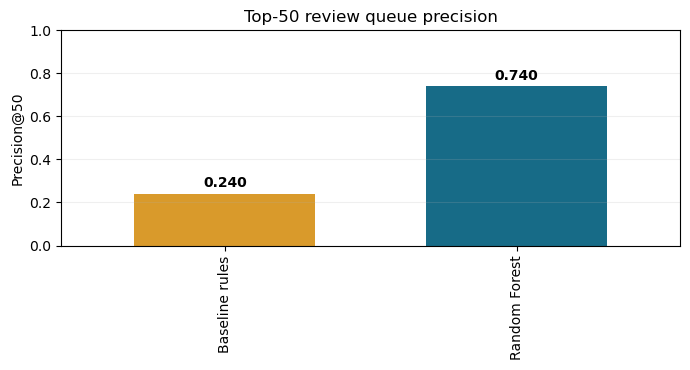

Wrote queue: c:\Users\LENOVO\OneDrive\Documents\INTERNSHIP\work\outputs\w07_ranked_action_queue.csv
Wrote metrics: c:\Users\LENOVO\OneDrive\Documents\INTERNSHIP\work\outputs\w07_playbook_metrics.json
Figures available: 6


In [12]:
work_outputs = REPO_ROOT / "work" / "outputs"
work_figures = REPO_ROOT / "work" / "figures"
work_outputs.mkdir(parents=True, exist_ok=True)
work_figures.mkdir(parents=True, exist_ok=True)

queue_export = work_outputs / "w07_ranked_action_queue.csv"
metrics_export = work_outputs / "w07_playbook_metrics.json"
queue.to_csv(queue_export, index=False)
metrics_export.write_text(json.dumps(metrics, indent=2), encoding="utf-8")

# The source charts are copied into the paper-facing figures directory when available.
source_figures = REPO_ROOT / "outputs" / "charts"
for chart_name in ["action_mix.svg", "confidence_mix.svg", "top_feature_importance.svg", "top_reason_codes.svg", "trend_distribution.svg"]:
    source_chart = source_figures / chart_name
    if source_chart.exists():
        shutil.copy2(source_chart, work_figures / chart_name)

fig, ax = plt.subplots(figsize=(7, 3.8))
comparison = pd.Series({"Baseline rules": metrics["baseline_precision_at_50"], "Random Forest": metrics["model_precision_at_50"],})
comparison.plot(kind="bar", ax=ax, color=["#D99A2B", "#176B87"], width=0.62)
ax.set_ylim(0, 1)
ax.set_ylabel("Precision@50")
ax.set_title("Top-50 review queue precision")
ax.grid(axis="y", alpha=0.2)
for index, value in enumerate(comparison):
    ax.text(index, value + 0.03, f"{value:.3f}", ha="center", fontweight="bold")
fig.tight_layout()
fig.savefig(work_figures / "precision_at_50_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Wrote queue: {queue_export}")
print(f"Wrote metrics: {metrics_export}")
print(f"Figures available: {len(list(work_figures.iterdir()))}")

## Self-check and observation notes

- [x] Ranked actions and reason codes are explained in plain language.
- [x] Intended use, limits, human review, no-go cases, monitoring, and retrain triggers are stated.
- [x] The queue export and metrics receipt are regenerated by code.
- [x] Claims use observed, measured, directional, and decision-support language.
- [x] The current-window label boundary is explicit.
- [x] Notebook code cells ran successfully top to bottom.
- [ ] Commit the notebook and paper-facing metrics/figures; keep generated queue data out of git.

### Observation notes

The most useful observation is operational rather than glamorous: the queue is only valuable when a reviewer can understand why a page appears and can safely disagree with it. The model's measured top-50 lift supports better ordering of review attention on the recorded client-holdout split, but it does not decide what to publish. The thin-signal and tracking-anomaly cases are where the playbook should slow down, not pretend to be certain. The strongest next iteration is a time-aware label with a genuine future outcome.